<a href="https://colab.research.google.com/github/RA-1020/tiny-wfm-backbone/blob/main/stage_e_sionna_channel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi
!rm -rf tiny-wfm-backbone
!git clone https://github.com/RA-1020/tiny-wfm-backbone.git
%cd tiny-wfm-backbone
!pip install sionna timm wandb -q

Fri Jul 10 09:54:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sionna
print("Sionna version:", sionna.__version__)

import sionna.phy
print([m for m in dir(sionna.phy) if not m.startswith("_")])
import sionna.phy.channel
print([m for m in dir(sionna.phy.channel) if not m.startswith("_")])

Sionna version: 2.0.1


ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)

In [1]:
%cd /content/tiny-wfm-backbone

import sionna
print("Sionna version:", sionna.__version__)

import sionna.phy
print([m for m in dir(sionna.phy) if not m.startswith("_")])
import sionna.phy.channel
print([m for m in dir(sionna.phy.channel) if not m.startswith("_")])

/content/tiny-wfm-backbone
Sionna version: 2.0.1
['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']
['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import torch
from sionna.phy.channel.tr38901 import TDL
from sionna.phy.channel import (cir_to_time_channel, ApplyTimeChannel,
                                time_lag_discrete_time_channel)

# ---- Contract params (Stage E) ----
CARRIER = 3.5e9        # 3.5 GHz carrier frequency
DELAY_SPREAD = 300e-9  # 300 ns delay spread (urban macro)
FS = 20e6              # assumed sample rate: 20 MHz
SNR_DB = 10.0
SPEED = 3.0            # m/s receiver speed (pedestrian) - mild Doppler
N = 1024               # samples per frame

# ---- Load 8 clean IQ frames ----
data = np.load("/content/drive/MyDrive/wfm-data/radioml_subset.npz")
Xb = data["X"][:8]                                   # (8, 1024, 2)
x = torch.complex(torch.tensor(Xb[..., 0]), torch.tensor(Xb[..., 1]))  # (8, 1024)
x = x / torch.sqrt((x.abs()**2).mean(dim=1, keepdim=True))  # unit power per frame
print("x:", x.shape, x.dtype)

# ---- Build the discrete-time channel ----
l_min, l_max = time_lag_discrete_time_channel(FS)
l_tot = l_max - l_min + 1
print("l_min, l_max, l_tot:", l_min, l_max, l_tot)

tdl = TDL(model="C", delay_spread=DELAY_SPREAD, carrier_frequency=CARRIER,
          min_speed=SPEED, max_speed=SPEED)

a, tau = tdl(batch_size=8, num_time_steps=N + l_tot - 1, sampling_frequency=FS)
print("a:", a.shape, "| tau:", tau.shape)

h_time = cir_to_time_channel(FS, a, tau, l_min=l_min, l_max=l_max, normalize=True)
print("h_time:", h_time.shape)

# ---- Pass the frames through channel + noise ----
apply_ch = ApplyTimeChannel(num_time_samples=N, l_tot=l_tot, add_awgn=True)
no = 10 ** (-SNR_DB / 10)
x_in = x[:, None, None, :]          # add (num_tx, num_tx_ant) dims -> (8,1,1,1024)
y = apply_ch(x_in, h_time, no)
print("y:", y.shape, y.dtype)

y_frames = y[:, 0, 0, :N]           # squeeze back down, trim tail -> (8, 1024)
print("y_frames:", y_frames.shape)

x: torch.Size([8, 1024]) torch.complex64
l_min, l_max, l_tot: -6 66 73
a: torch.Size([8, 1, 1, 1, 1, 24, 1096]) | tau: torch.Size([8, 1, 1, 24])
h_time: torch.Size([8, 1, 1, 1, 1, 1096, 73])
y: torch.Size([8, 1, 1, 1096]) torch.complex64
y_frames: torch.Size([8, 1024])


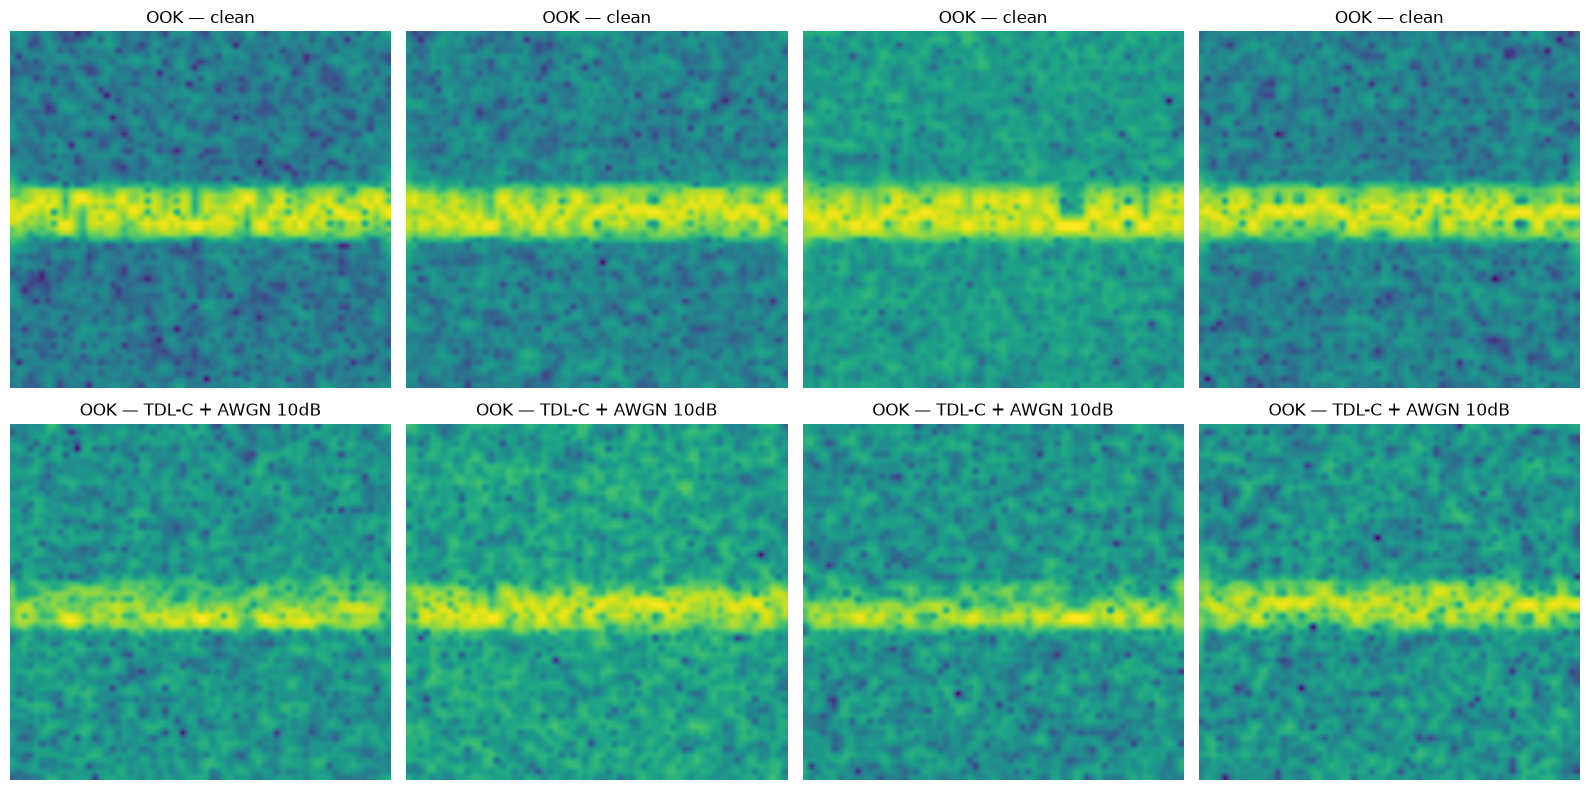

In [6]:
import matplotlib.pyplot as plt
from dataset import iq_to_spectrogram

classes = [str(c) for c in data["classes"]]
labels = data["y"][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col in range(4):
    clean_img = iq_to_spectrogram(x[col])                  # top row: clean
    chan_img  = iq_to_spectrogram(y_frames[col].cpu())     # bottom row: through channel (moved to CPU)
    axes[0, col].imshow(clean_img[0], aspect="auto", cmap="viridis")
    axes[0, col].set_title(f"{classes[labels[col]]} — clean")
    axes[1, col].imshow(chan_img[0], aspect="auto", cmap="viridis")
    axes[1, col].set_title(f"{classes[labels[col]]} — TDL-C + AWGN 10dB")
    axes[0, col].axis("off"); axes[1, col].axis("off")
plt.tight_layout()
plt.savefig("channel_sanity.png", dpi=120)
plt.show()

In [7]:
import numpy as np
import torch

X_all = data["X"]                       # (12000, 1024, 2)
y_all = data["y"]
N_total = len(X_all)
CHUNK = 500

out = np.empty_like(X_all)              # will hold channel-degraded IQ

apply_ch = ApplyTimeChannel(num_time_samples=N, l_tot=l_tot, add_awgn=True)
no = 10 ** (-SNR_DB / 10)

for start in range(0, N_total, CHUNK):
    end = min(start + CHUNK, N_total)
    b = end - start

    xb = torch.complex(torch.tensor(X_all[start:end, :, 0]),
                       torch.tensor(X_all[start:end, :, 1]))
    xb = xb / torch.sqrt((xb.abs()**2).mean(dim=1, keepdim=True))   # unit power

    a, tau = tdl(batch_size=b, num_time_steps=N + l_tot - 1, sampling_frequency=FS)
    h_time = cir_to_time_channel(FS, a, tau, l_min=l_min, l_max=l_max, normalize=True)

    yb = apply_ch(xb[:, None, None, :], h_time, no)
    yb = yb[:, 0, 0, :N].cpu()                                      # (b, 1024) complex, on CPU

    out[start:end, :, 0] = yb.real.numpy()
    out[start:end, :, 1] = yb.imag.numpy()

    if start % 2000 == 0:
        print(f"{end}/{N_total} done")

np.savez_compressed("radioml_subset_channel.npz",
                    X=out, y=y_all, classes=data["classes"],
                    channel="TDL-C NLOS", carrier_hz=CARRIER,
                    delay_spread_s=DELAY_SPREAD, fs_hz=FS, snr_db=SNR_DB, speed_mps=SPEED)
print("saved", np.round(__import__('os').path.getsize('radioml_subset_channel.npz')/1e6, 1), "MB")

# copy to Drive so it survives the session
!cp radioml_subset_channel.npz "/content/drive/MyDrive/wfm-data/"
!ls -la "/content/drive/MyDrive/wfm-data/"

500/12000 done
2500/12000 done
4500/12000 done
6500/12000 done
8500/12000 done
10500/12000 done
saved 90.8 MB
total 176937
-rw------- 1 root root 90788853 Jul 10 10:09 radioml_subset_channel.npz
-rw------- 1 root root 90394152 Jul  5 08:26 radioml_subset.npz


In [8]:
import torch.nn as nn
import timm
import wandb
from torch.utils.data import DataLoader, random_split
from dataset import RadioMLSpectrograms

device = torch.device("cuda")

full_ds = RadioMLSpectrograms("/content/drive/MyDrive/wfm-data/radioml_subset_channel.npz")
print(len(full_ds), full_ds.classes)

g = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(full_ds, [0.8, 0.2], generator=g)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)

model = timm.create_model("vit_tiny_patch16_224", pretrained=True,
                          num_classes=10, in_chans=1).to(device)

EPOCHS = 8
LR = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

run = wandb.init(project="tiny-wfm-backbone", name="stage-e-channel-baseline",
                 config={"model": "vit_tiny_patch16_224", "pretrained": True,
                         "in_chans": 1, "lr": LR, "epochs": EPOCHS,
                         "data": "radioml_subset_channel TDL-C NLOS 10dB fs20MHz"})

def evaluate():
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x_, y_ in val_loader:
            x_, y_ = x_.to(device), y_.to(device)
            pred = model(x_).argmax(dim=1)
            correct += (pred == y_).sum().item()
            total += y_.size(0)
    return correct / total

for epoch in range(EPOCHS):
    model.train()
    running_loss = correct = total = 0
    for x_, y_ in train_loader:
        x_, y_ = x_.to(device), y_.to(device)
        logits = model(x_)
        loss = criterion(logits, y_)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * y_.size(0)
        correct += (logits.argmax(dim=1) == y_).sum().item()
        total += y_.size(0)

    val_acc = evaluate()
    wandb.log({"epoch": epoch, "train_loss": running_loss/total,
               "train_acc": correct/total, "val_acc": val_acc})
    print(f"epoch {epoch}: loss {running_loss/total:.3f} | train {correct/total:.1%} | val {val_acc:.1%}")

12000 ['OOK', 'BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', 'AM-DSB-WC', 'FM', 'GMSK', 'OQPSK']


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ra-1020 (ra-10) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch 0: loss 1.142 | train 53.4% | val 62.1%
epoch 1: loss 0.785 | train 66.0% | val 68.1%
epoch 2: loss 0.688 | train 70.4% | val 68.4%
epoch 3: loss 0.610 | train 73.0% | val 69.3%
epoch 4: loss 0.539 | train 75.6% | val 70.1%
epoch 5: loss 0.455 | train 79.9% | val 70.8%
epoch 6: loss 0.374 | train 83.1% | val 70.1%
epoch 7: loss 0.313 | train 86.6% | val 69.6%


       OOK: 97.4%
      BPSK: 55.6%
      QPSK: 99.2%
      8PSK: 49.8%
     16QAM: 50.6%
     64QAM: 99.6%
 AM-DSB-WC: 100.0%
        FM: 90.8%
      GMSK: 32.7%
     OQPSK: 13.2%


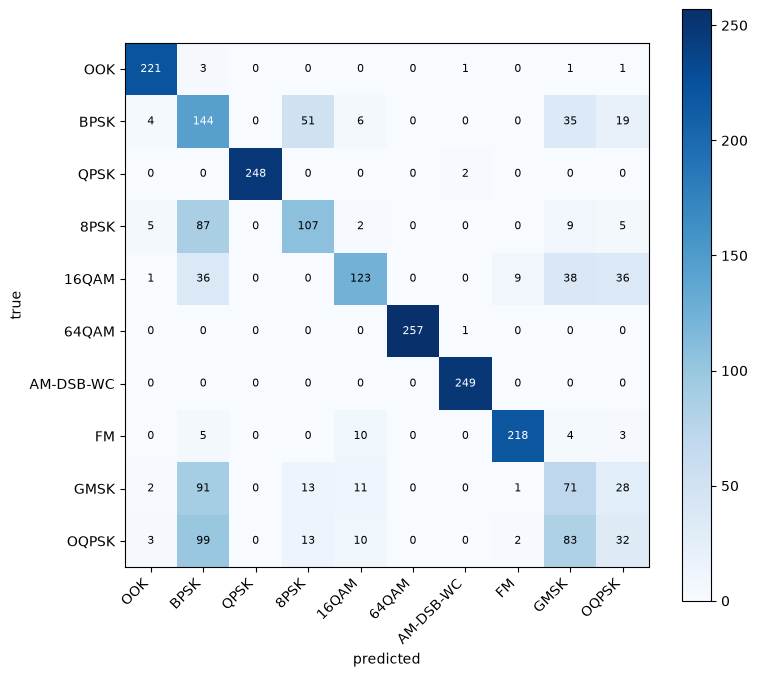

epoch,▁▂▃▄▅▆▇█
train_acc,▁▄▅▅▆▇▇█
train_loss,█▅▄▄▃▂▂▁
val_acc,▁▆▆▇▇█▇▇
epoch,7
train_acc,0.86635
train_loss,0.31313
val_acc,0.69583


In [9]:
import matplotlib.pyplot as plt

model.eval()
C = torch.zeros(10, 10, dtype=torch.int32)
with torch.no_grad():
    for x_, y_ in val_loader:
        pred = model(x_.to(device)).argmax(dim=1).cpu()
        for t, p in zip(y_, pred):
            C[t, p] += 1

per_class_acc = C.diag().float() / C.sum(dim=1).float()
for name, acc in zip(full_ds.classes, per_class_acc):
    print(f"{name:>10}: {acc:.1%}")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(full_ds.classes, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(full_ds.classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(10):
    for j in range(10):
        ax.text(j, i, C[i, j].item(), ha="center", va="center",
                color="white" if C[i, j] > C.max()//2 else "black", fontsize=8)
plt.colorbar(im); plt.tight_layout()
plt.savefig("confusion_matrix_channel.png", dpi=120)
plt.show()

wandb.log({"confusion_matrix": wandb.Image("confusion_matrix_channel.png")})
wandb.finish()